# Eksperymenty SMA dla trzech presetów labiryntów

Notebook uruchamia algorytm `MazeSMA` 10 razy dla trzech zdefiniowanych labiryntów:
- `large_open`
- `large_dfs`
- `large_prim`

Dla każdego uruchomienia zbierane są metryki:
- czas działania,
- długość znalezionej ścieżki,
- fitness,
- liczba wykorzystanych iteracji,
- informacja, czy algorytm dotarł do celu,
- relacja długości ścieżki SMA do optimum wyznaczonego przez A*.

Na końcu notebook przedstawia surowe wyniki i agregaty dla każdego labiryntu.


In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from maze_generator import get_preset_mazes, build_maze
from sma_algorithm import MazeSMA
from classic_algorithms import solve_astar, solve_dijkstra, solve_bfs

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
sns.set_theme(style='whitegrid')


In [2]:
PRESETS_TO_TEST = ['xl_open', 'xl_dfs', 'large_prim']
RUNS_PER_MAZE = 10
BASE_SEED = 20260327

presets = get_preset_mazes()
presets_subset = {key: presets[key] for key in PRESETS_TO_TEST}
pd.DataFrame(presets_subset).T[['name', 'generator', 'rows', 'cols', 'difficulty', 'recommended_params']]


,name,generator,rows,cols,difficulty,recommended_params
xl_open,Ekstra duży otwarty (51x51),open,51,51,trudny,"{'population_size': 100, 'max_iterations': 400..."
xl_dfs,Ekstra duży DFS (51x51),dfs,51,51,ekstremalny,"{'population_size': 120, 'max_iterations': 500..."
large_prim,Duży Prim (31x31),prim,31,31,trudny,"{'population_size': 100, 'max_iterations': 400..."


In [3]:
def run_single_sma(preset_key: str, run_id: int, base_seed: int = BASE_SEED) -> dict:
    config = presets[preset_key]
    maze, start, end = build_maze(preset_key)
    params = config['recommended_params']

    run_seed = base_seed + run_id
    random.seed(run_seed)
    np.random.seed(run_seed)

    solver = MazeSMA(
        maze=maze,
        start=start,
        end=end,
        population_size=params['population_size'],
        max_iterations=params['max_iterations'],
        z=params['z'],
    )
    result = solver.solve()

    astar_result = solve_astar(maze, start, end)
    dijkstra_result = solve_dijkstra(maze, start, end)
    bfs_result = solve_bfs(maze, start, end)

    found_end = bool(result.best_path) and result.best_path[-1] == end
    path_length = len(result.best_path) if result.best_path else 0
    optimal_length = astar_result.path_length or np.nan
    optimality_ratio = path_length / optimal_length if found_end and optimal_length and not np.isnan(optimal_length) else np.nan

    return {
        'preset_key': preset_key,
        'maze_name': config['name'],
        'generator': config['generator'],
        'difficulty': config['difficulty'],
        'run_id': run_id,
        'seed': run_seed,
        'population_size': params['population_size'],
        'max_iterations': params['max_iterations'],
        'z': params['z'],
        'rows': maze.shape[0],
        'cols': maze.shape[1],
        'found_end': found_end,
        'path_length': path_length if found_end else np.nan,
        'fitness': result.best_fitness,
        'execution_time_s': result.execution_time,
        'iterations_used': result.iterations_used,
        'final_convergence_value': result.convergence_history[-1] if result.convergence_history else np.nan,
        'optimal_path_length_astar': astar_result.path_length,
        'optimal_path_length_dijkstra': dijkstra_result.path_length,
        'optimal_path_length_bfs': bfs_result.path_length,
        'optimality_ratio_to_astar': optimality_ratio,
    }


def run_benchmark(preset_keys, runs_per_maze=10):
    rows = []
    for preset_key in preset_keys:
        for run_id in range(1, runs_per_maze + 1):
            rows.append(run_single_sma(preset_key, run_id))
    return pd.DataFrame(rows)


def summarize_results(results_df: pd.DataFrame) -> pd.DataFrame:
    summaries = []
    for preset_key, group in results_df.groupby('preset_key', sort=False):
        valid_paths = group.dropna(subset=['path_length'])
        fastest_idx = group['execution_time_s'].idxmin()
        fastest_run = int(group.loc[fastest_idx, 'run_id'])

        if not valid_paths.empty:
            shortest_path_idx = valid_paths['path_length'].idxmin()
            shortest_path_run = int(valid_paths.loc[shortest_path_idx, 'run_id'])
            shortest_path_length = float(valid_paths.loc[shortest_path_idx, 'path_length'])
            mean_path_length = float(valid_paths['path_length'].mean())
        else:
            shortest_path_run = np.nan
            shortest_path_length = np.nan
            mean_path_length = np.nan

        summaries.append({
            'preset_key': preset_key,
            'maze_name': group['maze_name'].iloc[0],
            'generator': group['generator'].iloc[0],
            'runs': len(group),
            'success_count': int(group['found_end'].sum()),
            'success_rate': group['found_end'].mean(),
            'mean_time_s': group['execution_time_s'].mean(),
            'std_time_s': group['execution_time_s'].std(ddof=0),
            'min_time_s': group['execution_time_s'].min(),
            'fastest_run_id': fastest_run,
            'mean_path_length': mean_path_length,
            'shortest_path_length': shortest_path_length,
            'shortest_path_run_id': shortest_path_run,
            'mean_fitness': group['fitness'].mean(),
            'best_fitness': group['fitness'].min(),
            'mean_iterations_used': group['iterations_used'].mean(),
            'max_iterations_used': group['iterations_used'].max(),
            'mean_optimality_ratio_to_astar': group['optimality_ratio_to_astar'].mean(),
            'population_size': group['population_size'].iloc[0],
            'max_iterations': group['max_iterations'].iloc[0],
            'z': group['z'].iloc[0],
        })

    return pd.DataFrame(summaries).sort_values('preset_key').reset_index(drop=True)


In [4]:
results_df = run_benchmark(PRESETS_TO_TEST, runs_per_maze=RUNS_PER_MAZE)
results_df


,preset_key,maze_name,generator,difficulty,run_id,seed,population_size,max_iterations,z,rows,cols,found_end,path_length,fitness,execution_time_s,iterations_used,final_convergence_value,optimal_path_length_astar,optimal_path_length_dijkstra,optimal_path_length_bfs,optimality_ratio_to_astar
0,xl_open,Ekstra duży otwarty (51x51),open,trudny,1,20260328,100,400,0.0300,51,51,True,107,107,1.5193,36,107,107,107,107,1.0000
1,xl_open,Ekstra duży otwarty (51x51),open,trudny,2,20260329,100,400,0.0300,51,51,True,109,109,1.5240,37,109,107,107,107,1.0187
2,xl_open,Ekstra duży otwarty (51x51),open,trudny,3,20260330,100,400,0.0300,51,51,True,107,107,1.5122,37,107,107,107,107,1.0000
3,xl_open,Ekstra duży otwarty (51x51),open,trudny,4,20260331,100,400,0.0300,51,51,True,111,111,1.5330,42,111,107,107,107,1.0374
4,xl_open,Ekstra duży otwarty (51x51),open,trudny,5,20260332,100,400,0.0300,51,51,True,107,107,1.3340,39,107,107,107,107,1.0000
5,xl_open,Ekstra duży otwarty (51x51),open,trudny,6,20260333,100,400,0.0300,51,51,True,107,107,1.8924,53,107,107,107,107,1.0000
6,xl_open,Ekstra duży otwarty (51x51),open,trudny,7,20260334,100,400,0.0300,51,51,True,107,107,1.5073,39,107,107,107,107,1.0000
7,xl_open,Ekstra duży otwarty (51x51),open,trudny,8,20260335,100,400,0.0300,51,51,True,107,107,1.2972,37,107,107,107,107,1.0000
8,xl_open,Ekstra duży otwarty (51x51),open,trudny,9,20260336,100,400,0.0300,51,51,True,107,107,1.2113,29,107,107,107,107,1.0000
9,xl_open,Ekstra duży otwarty (51x51),open,trudny,10,20260337,100,400,0.0300,51,51,True,109,109,1.8865,56,109,107,107,107,1.0187


In [5]:
summary_df = summarize_results(results_df)
summary_df


,preset_key,maze_name,generator,runs,success_count,success_rate,mean_time_s,std_time_s,min_time_s,fastest_run_id,mean_path_length,shortest_path_length,shortest_path_run_id,mean_fitness,best_fitness,mean_iterations_used,max_iterations_used,mean_optimality_ratio_to_astar,population_size,max_iterations,z
0,large_prim,Duży Prim (31x31),prim,10,10,1.0000,0.2981,0.0200,0.2752,5,57.0000,57.0000,1,57.0000,57,22.0000,22,1.0000,100,400,0.0300
1,xl_dfs,Ekstra duży DFS (51x51),dfs,10,10,1.0000,1.5750,0.0472,1.5073,8,673.0000,673.0000,1,673.0000,673,22.0000,22,1.0000,120,500,0.0300
2,xl_open,Ekstra duży otwarty (51x51),open,10,10,1.0000,1.5217,0.2128,1.2113,9,107.8000,107.0000,1,107.8000,107,40.5000,56,1.0075,100,400,0.0300


In [6]:
for preset_key in PRESETS_TO_TEST:
    maze_summary = summary_df[summary_df['preset_key'] == preset_key]
    maze_runs = results_df[results_df['preset_key'] == preset_key].sort_values('run_id')

    print(f'=== {preset_key} | {maze_summary.iloc[0]["maze_name"]} ===')
    display(maze_summary)
    display(maze_runs[['run_id', 'seed', 'found_end', 'execution_time_s', 'path_length', 'fitness', 'iterations_used', 'optimality_ratio_to_astar']])


=== xl_open | Ekstra duży otwarty (51x51) ===


,preset_key,maze_name,generator,runs,success_count,success_rate,mean_time_s,std_time_s,min_time_s,fastest_run_id,mean_path_length,shortest_path_length,shortest_path_run_id,mean_fitness,best_fitness,mean_iterations_used,max_iterations_used,mean_optimality_ratio_to_astar,population_size,max_iterations,z
2,xl_open,Ekstra duży otwarty (51x51),open,10,10,1.0000,1.5217,0.2128,1.2113,9,107.8000,107.0000,1,107.8000,107,40.5000,56,1.0075,100,400,0.0300


,run_id,seed,found_end,execution_time_s,path_length,fitness,iterations_used,optimality_ratio_to_astar
0,1,20260328,True,1.5193,107,107,36,1.0000
1,2,20260329,True,1.5240,109,109,37,1.0187
2,3,20260330,True,1.5122,107,107,37,1.0000
3,4,20260331,True,1.5330,111,111,42,1.0374
4,5,20260332,True,1.3340,107,107,39,1.0000
5,6,20260333,True,1.8924,107,107,53,1.0000
6,7,20260334,True,1.5073,107,107,39,1.0000
7,8,20260335,True,1.2972,107,107,37,1.0000
8,9,20260336,True,1.2113,107,107,29,1.0000
9,10,20260337,True,1.8865,109,109,56,1.0187


=== xl_dfs | Ekstra duży DFS (51x51) ===


,preset_key,maze_name,generator,runs,success_count,success_rate,mean_time_s,std_time_s,min_time_s,fastest_run_id,mean_path_length,shortest_path_length,shortest_path_run_id,mean_fitness,best_fitness,mean_iterations_used,max_iterations_used,mean_optimality_ratio_to_astar,population_size,max_iterations,z
1,xl_dfs,Ekstra duży DFS (51x51),dfs,10,10,1.0000,1.5750,0.0472,1.5073,8,673.0000,673.0000,1,673.0000,673,22.0000,22,1.0000,120,500,0.0300


,run_id,seed,found_end,execution_time_s,path_length,fitness,iterations_used,optimality_ratio_to_astar
10,1,20260328,True,1.6849,673,673,22,1.0000
11,2,20260329,True,1.5566,673,673,22,1.0000
12,3,20260330,True,1.6278,673,673,22,1.0000
13,4,20260331,True,1.5645,673,673,22,1.0000
14,5,20260332,True,1.5618,673,673,22,1.0000
15,6,20260333,True,1.5781,673,673,22,1.0000
16,7,20260334,True,1.5377,673,673,22,1.0000
17,8,20260335,True,1.5073,673,673,22,1.0000
18,9,20260336,True,1.5479,673,673,22,1.0000
19,10,20260337,True,1.5835,673,673,22,1.0000


=== large_prim | Duży Prim (31x31) ===


,preset_key,maze_name,generator,runs,success_count,success_rate,mean_time_s,std_time_s,min_time_s,fastest_run_id,mean_path_length,shortest_path_length,shortest_path_run_id,mean_fitness,best_fitness,mean_iterations_used,max_iterations_used,mean_optimality_ratio_to_astar,population_size,max_iterations,z
0,large_prim,Duży Prim (31x31),prim,10,10,1.0000,0.2981,0.0200,0.2752,5,57.0000,57.0000,1,57.0000,57,22.0000,22,1.0000,100,400,0.0300


,run_id,seed,found_end,execution_time_s,path_length,fitness,iterations_used,optimality_ratio_to_astar
20,1,20260328,True,0.3018,57,57,22,1.0000
21,2,20260329,True,0.2919,57,57,22,1.0000
22,3,20260330,True,0.3015,57,57,22,1.0000
23,4,20260331,True,0.2813,57,57,22,1.0000
24,5,20260332,True,0.2752,57,57,22,1.0000
25,6,20260333,True,0.3489,57,57,22,1.0000
26,7,20260334,True,0.2890,57,57,22,1.0000
27,8,20260335,True,0.2828,57,57,22,1.0000
28,9,20260336,True,0.2959,57,57,22,1.0000
29,10,20260337,True,0.3128,57,57,22,1.0000


C:\Users\julia\AppData\Local\Temp\ipykernel_3652\3642712575.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_df, x='preset_key', y='mean_time_s', ax=axes[0], palette='crest')
C:\Users\julia\AppData\Local\Temp\ipykernel_3652\3642712575.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_df, x='preset_key', y='mean_path_length', ax=axes[1], palette='flare')


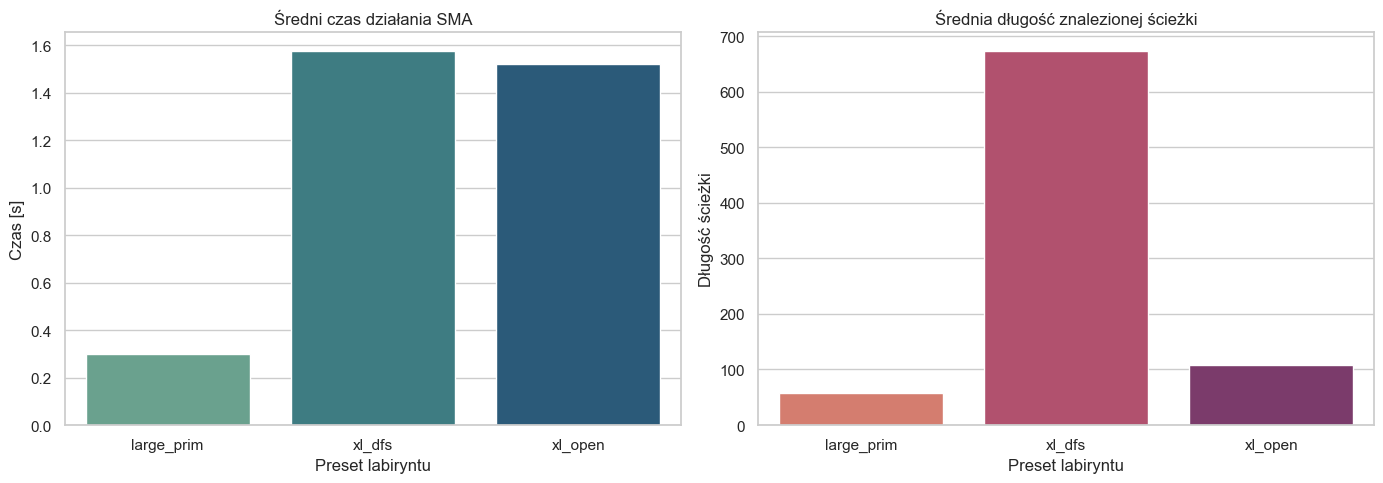

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=summary_df, x='preset_key', y='mean_time_s', ax=axes[0], palette='crest')
axes[0].set_title('Średni czas działania SMA')
axes[0].set_xlabel('Preset labiryntu')
axes[0].set_ylabel('Czas [s]')

sns.barplot(data=summary_df, x='preset_key', y='mean_path_length', ax=axes[1], palette='flare')
axes[1].set_title('Średnia długość znalezionej ścieżki')
axes[1].set_xlabel('Preset labiryntu')
axes[1].set_ylabel('Długość ścieżki')

plt.tight_layout()
plt.show()


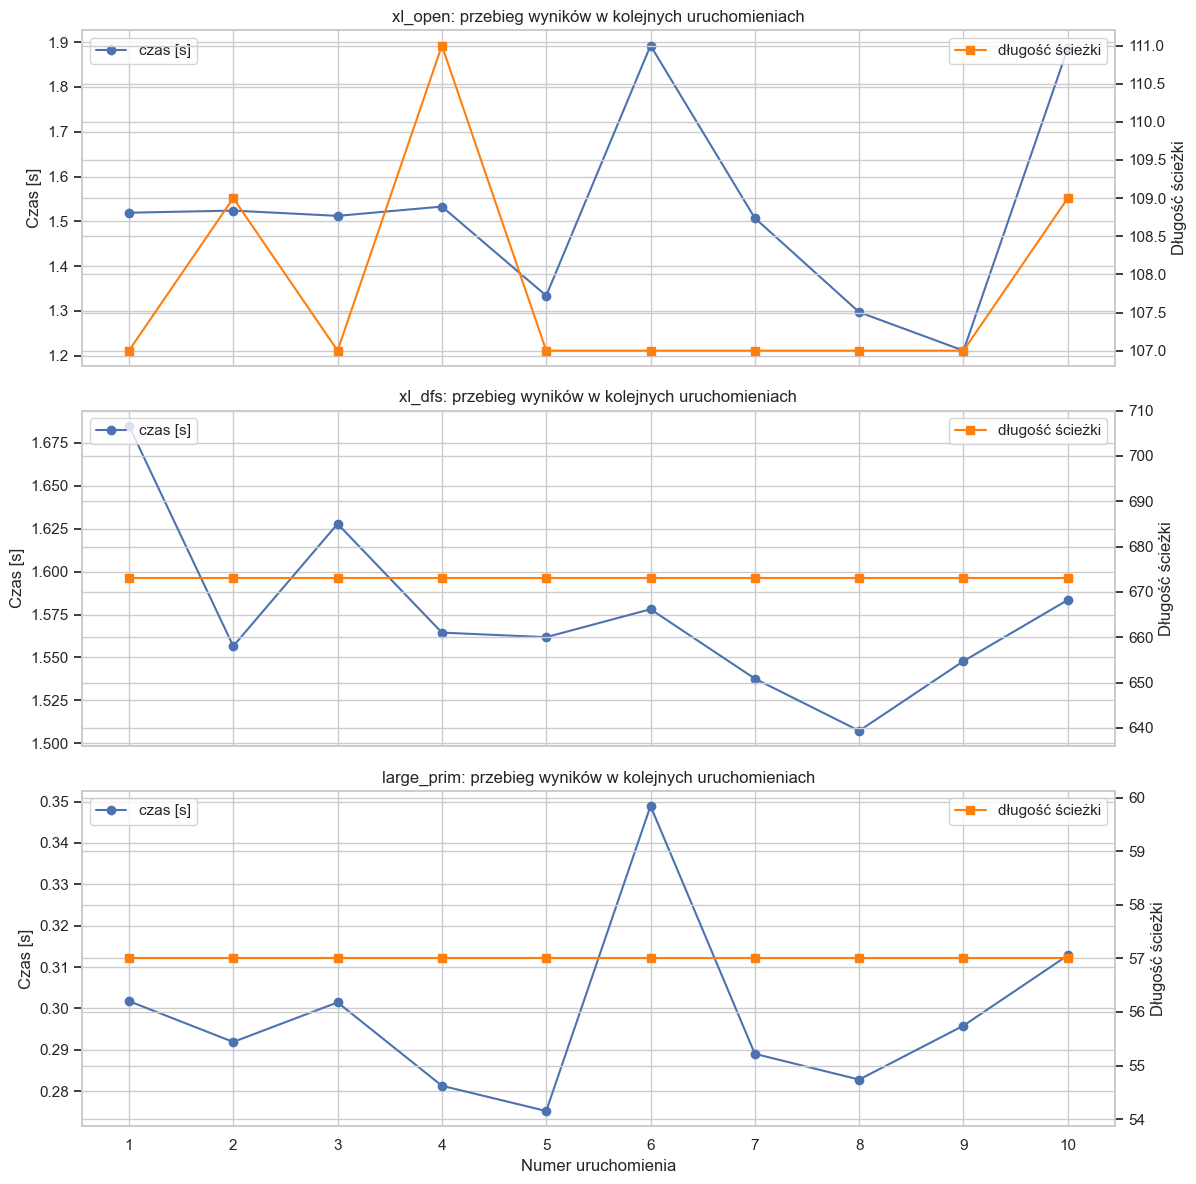

In [8]:
fig, axes = plt.subplots(len(PRESETS_TO_TEST), 1, figsize=(12, 4 * len(PRESETS_TO_TEST)), sharex=True)

if len(PRESETS_TO_TEST) == 1:
    axes = [axes]

for ax, preset_key in zip(axes, PRESETS_TO_TEST):
    subset = results_df[results_df['preset_key'] == preset_key].sort_values('run_id')
    ax.plot(subset['run_id'], subset['execution_time_s'], marker='o', label='czas [s]')
    ax2 = ax.twinx()
    ax2.plot(subset['run_id'], subset['path_length'], marker='s', color='tab:orange', label='długość ścieżki')

    ax.set_title(f'{preset_key}: przebieg wyników w kolejnych uruchomieniach')
    ax.set_ylabel('Czas [s]')
    ax2.set_ylabel('Długość ścieżki')
    ax.set_xticks(subset['run_id'])
    ax.legend(loc='upper left')
    ax2.legend(loc='upper right')

axes[-1].set_xlabel('Numer uruchomienia')
plt.tight_layout()
plt.show()


## Analiza wpływu parametrów SMA

Poniższa sekcja bada wpływ trzech parametrów algorytmu na jakość i koszt obliczeń:
- `max_iterations`: zbyt mała liczba iteracji może nie wystarczyć do znalezienia rozwiązania,
- `population_size`: zbyt mała populacja ogranicza eksplorację przestrzeni ścieżek,
- `z`: zbyt małe lub zbyt duże prawdopodobieństwo losowej eksploracji może pogorszyć skuteczność.

Eksperyment zmienia zawsze tylko jeden parametr naraz, a pozostałe utrzymuje na poziomie rekomendowanym dla wybranego labiryntu. Dzięki temu łatwiej zinterpretować wynik.


In [13]:
PARAM_SENSITIVITY_PRESET = 'xl_open'
PARAM_SENSITIVITY_RUNS = 5

base_params = presets[PARAM_SENSITIVITY_PRESET]['recommended_params'].copy()
param_grid = {
    'max_iterations': [10, 25, 50, base_params['max_iterations'] // 2, base_params['max_iterations'], int(base_params['max_iterations'] * 1.5)],
    'population_size': [10, 20, max(30, base_params['population_size'] // 2), base_params['population_size'], int(base_params['population_size'] * 1.5)],
    'z': [0.005, 0.01, 0.03, 0.1, 0.2],
}

param_grid


{'max_iterations': [10, 25, 50, 200, 400, 600],
 'population_size': [10, 20, 50, 100, 150],
 'z': [0.005, 0.01, 0.03, 0.1, 0.2]}

In [14]:
def run_single_sma_with_params(
    preset_key: str,
    run_id: int,
    population_size: int,
    max_iterations: int,
    z: float,
    base_seed: int = BASE_SEED,
) -> dict:
    config = presets[preset_key]
    maze, start, end = build_maze(preset_key)

    run_seed = base_seed + run_id
    random.seed(run_seed)
    np.random.seed(run_seed)

    solver = MazeSMA(
        maze=maze,
        start=start,
        end=end,
        population_size=population_size,
        max_iterations=max_iterations,
        z=z,
    )
    result = solver.solve()
    astar_result = solve_astar(maze, start, end)

    found_end = bool(result.best_path) and result.best_path[-1] == end
    path_length = len(result.best_path) if result.best_path else 0
    optimal_length = astar_result.path_length or np.nan
    optimality_ratio = path_length / optimal_length if found_end and optimal_length and not np.isnan(optimal_length) else np.nan

    return {
        'preset_key': preset_key,
        'maze_name': config['name'],
        'run_id': run_id,
        'seed': run_seed,
        'population_size': population_size,
        'max_iterations': max_iterations,
        'z': z,
        'found_end': found_end,
        'path_length': path_length if found_end else np.nan,
        'fitness': result.best_fitness,
        'execution_time_s': result.execution_time,
        'iterations_used': result.iterations_used,
        'optimal_path_length_astar': astar_result.path_length,
        'optimality_ratio_to_astar': optimality_ratio,
    }


def run_parameter_sensitivity(preset_key: str, param_grid: dict, runs_per_setting: int = 5) -> pd.DataFrame:
    rows = []
    defaults = presets[preset_key]['recommended_params'].copy()

    for parameter_name, values in param_grid.items():
        for value in values:
            params = defaults.copy()
            params[parameter_name] = value

            for run_id in range(1, runs_per_setting + 1):
                setting_seed = BASE_SEED + (len(parameter_name) * 1_000) + int(float(value) * 100)
                row = run_single_sma_with_params(
                    preset_key=preset_key,
                    run_id=run_id,
                    population_size=params['population_size'],
                    max_iterations=params['max_iterations'],
                    z=params['z'],
                    base_seed=setting_seed,
                )
                row['tested_parameter'] = parameter_name
                row['tested_value'] = value
                rows.append(row)

    return pd.DataFrame(rows)


def summarize_parameter_sensitivity(results_df: pd.DataFrame) -> pd.DataFrame:
    summaries = []

    for (parameter_name, tested_value), group in results_df.groupby(['tested_parameter', 'tested_value'], sort=False):
        valid_paths = group.dropna(subset=['path_length'])
        fastest_idx = group['execution_time_s'].idxmin()
        fastest_run = int(group.loc[fastest_idx, 'run_id'])

        if not valid_paths.empty:
            shortest_idx = valid_paths['path_length'].idxmin()
            shortest_run = int(valid_paths.loc[shortest_idx, 'run_id'])
            shortest_path = float(valid_paths.loc[shortest_idx, 'path_length'])
            mean_path = float(valid_paths['path_length'].mean())
        else:
            shortest_run = np.nan
            shortest_path = np.nan
            mean_path = np.nan

        summaries.append({
            'tested_parameter': parameter_name,
            'tested_value': tested_value,
            'runs': len(group),
            'success_count': int(group['found_end'].sum()),
            'success_rate': group['found_end'].mean(),
            'mean_time_s': group['execution_time_s'].mean(),
            'std_time_s': group['execution_time_s'].std(ddof=0),
            'fastest_run_id': fastest_run,
            'mean_path_length': mean_path,
            'shortest_path_length': shortest_path,
            'shortest_path_run_id': shortest_run,
            'mean_fitness': group['fitness'].mean(),
            'mean_iterations_used': group['iterations_used'].mean(),
            'mean_optimality_ratio_to_astar': group['optimality_ratio_to_astar'].mean(),
        })

    return pd.DataFrame(summaries)


sensitivity_results_df = run_parameter_sensitivity(
    preset_key=PARAM_SENSITIVITY_PRESET,
    param_grid=param_grid,
    runs_per_setting=PARAM_SENSITIVITY_RUNS,
)

sensitivity_summary_df = summarize_parameter_sensitivity(sensitivity_results_df)

print('Labirynt do analizy parametrów:', presets[PARAM_SENSITIVITY_PRESET]['name'])
display(sensitivity_results_df.head())
display(sensitivity_summary_df.sort_values(['tested_parameter', 'tested_value']))


Labirynt do analizy parametrów: Ekstra duży otwarty (51x51)


,preset_key,maze_name,run_id,seed,population_size,max_iterations,z,found_end,path_length,fitness,execution_time_s,iterations_used,optimal_path_length_astar,optimality_ratio_to_astar,tested_parameter,tested_value
0,xl_open,Ekstra duży otwarty (51x51),1,20275328,100,10,0.0300,True,117,117,0.7136,10,107,1.0935,max_iterations,10.0000
1,xl_open,Ekstra duży otwarty (51x51),2,20275329,100,10,0.0300,True,113,113,0.6831,10,107,1.0561,max_iterations,10.0000
2,xl_open,Ekstra duży otwarty (51x51),3,20275330,100,10,0.0300,True,119,119,0.7590,10,107,1.1121,max_iterations,10.0000
3,xl_open,Ekstra duży otwarty (51x51),4,20275331,100,10,0.0300,True,119,119,0.7434,10,107,1.1121,max_iterations,10.0000
4,xl_open,Ekstra duży otwarty (51x51),5,20275332,100,10,0.0300,True,115,115,0.6102,10,107,1.0748,max_iterations,10.0000


,tested_parameter,tested_value,runs,success_count,success_rate,mean_time_s,std_time_s,fastest_run_id,mean_path_length,shortest_path_length,shortest_path_run_id,mean_fitness,mean_iterations_used,mean_optimality_ratio_to_astar
0,max_iterations,10.0000,5,5,1.0000,0.7019,0.0527,5,116.6000,113.0000,2,116.6000,10.0000,1.0897
1,max_iterations,25.0000,5,5,1.0000,0.9786,0.0276,1,113.8000,109.0000,1,113.8000,25.0000,1.0636
2,max_iterations,50.0000,5,5,1.0000,1.2496,0.0531,3,107.4000,107.0000,1,107.4000,38.4000,1.0037
3,max_iterations,200.0000,5,5,1.0000,1.6603,0.3301,4,107.4000,107.0000,1,107.4000,45.6000,1.0037
4,max_iterations,400.0000,5,5,1.0000,1.5147,0.1783,1,108.2000,107.0000,3,108.2000,40.2000,1.0112
5,max_iterations,600.0000,5,5,1.0000,1.4612,0.2048,4,107.4000,107.0000,1,107.4000,36.8000,1.0037
6,population_size,10.0000,5,5,1.0000,0.2617,0.0157,1,109.0000,107.0000,1,109.0000,79.2000,1.0187
7,population_size,20.0000,5,5,1.0000,0.3556,0.0668,3,109.4000,107.0000,5,109.4000,51.0000,1.0224
8,population_size,50.0000,5,5,1.0000,0.8178,0.1923,1,107.8000,107.0000,1,107.8000,46.8000,1.0075
9,population_size,100.0000,5,5,1.0000,1.4667,0.0916,3,107.0000,107.0000,1,107.0000,39.8000,1.0000


In [11]:
for parameter_name in ['max_iterations', 'population_size', 'z']:
    print(f'=== Parametr: {parameter_name} ===')
    display(
        sensitivity_summary_df[
            sensitivity_summary_df['tested_parameter'] == parameter_name
        ].sort_values('tested_value')
    )


=== Parametr: max_iterations ===


,tested_parameter,tested_value,runs,success_count,success_rate,mean_time_s,std_time_s,fastest_run_id,mean_path_length,shortest_path_length,shortest_path_run_id,mean_fitness,mean_iterations_used,mean_optimality_ratio_to_astar
0,max_iterations,10.0000,5,5,1.0000,0.1880,0.0129,3,57.0000,57.0000,1,57.0000,10.0000,1.0000
1,max_iterations,25.0000,5,5,1.0000,0.2622,0.0073,2,57.0000,57.0000,1,57.0000,22.0000,1.0000
2,max_iterations,50.0000,5,5,1.0000,0.2958,0.0041,4,57.0000,57.0000,1,57.0000,22.0000,1.0000
3,max_iterations,200.0000,5,5,1.0000,0.2997,0.0087,4,57.0000,57.0000,1,57.0000,22.0000,1.0000
4,max_iterations,400.0000,5,5,1.0000,0.3007,0.0127,4,57.0000,57.0000,1,57.0000,22.0000,1.0000
5,max_iterations,600.0000,5,5,1.0000,0.3005,0.0074,3,57.0000,57.0000,1,57.0000,22.0000,1.0000


=== Parametr: population_size ===


,tested_parameter,tested_value,runs,success_count,success_rate,mean_time_s,std_time_s,fastest_run_id,mean_path_length,shortest_path_length,shortest_path_run_id,mean_fitness,mean_iterations_used,mean_optimality_ratio_to_astar
6,population_size,10.0000,5,5,1.0000,0.0322,0.0037,2,57.0000,57.0000,1,57.0000,22.0000,1.0000
7,population_size,20.0000,5,5,1.0000,0.0654,0.0099,5,57.0000,57.0000,1,57.0000,22.0000,1.0000
8,population_size,50.0000,5,5,1.0000,0.1481,0.0124,4,57.0000,57.0000,1,57.0000,22.0000,1.0000
9,population_size,100.0000,5,5,1.0000,0.3008,0.0148,5,57.0000,57.0000,1,57.0000,22.0000,1.0000
10,population_size,150.0000,5,5,1.0000,0.4394,0.0153,1,57.0000,57.0000,1,57.0000,22.0000,1.0000


=== Parametr: z ===


,tested_parameter,tested_value,runs,success_count,success_rate,mean_time_s,std_time_s,fastest_run_id,mean_path_length,shortest_path_length,shortest_path_run_id,mean_fitness,mean_iterations_used,mean_optimality_ratio_to_astar
11,z,0.0050,5,5,1.0000,0.2486,0.0154,5,57.0000,57.0000,1,57.0000,22.0000,1.0000
12,z,0.0100,5,5,1.0000,0.2542,0.0129,5,57.0000,57.0000,1,57.0000,22.0000,1.0000
13,z,0.0300,5,5,1.0000,0.2871,0.0024,3,57.0000,57.0000,1,57.0000,22.0000,1.0000
14,z,0.1000,5,5,1.0000,0.4462,0.0255,2,57.0000,57.0000,1,57.0000,22.0000,1.0000
15,z,0.2000,5,5,1.0000,0.6880,0.0154,3,57.0000,57.0000,1,57.0000,22.0000,1.0000


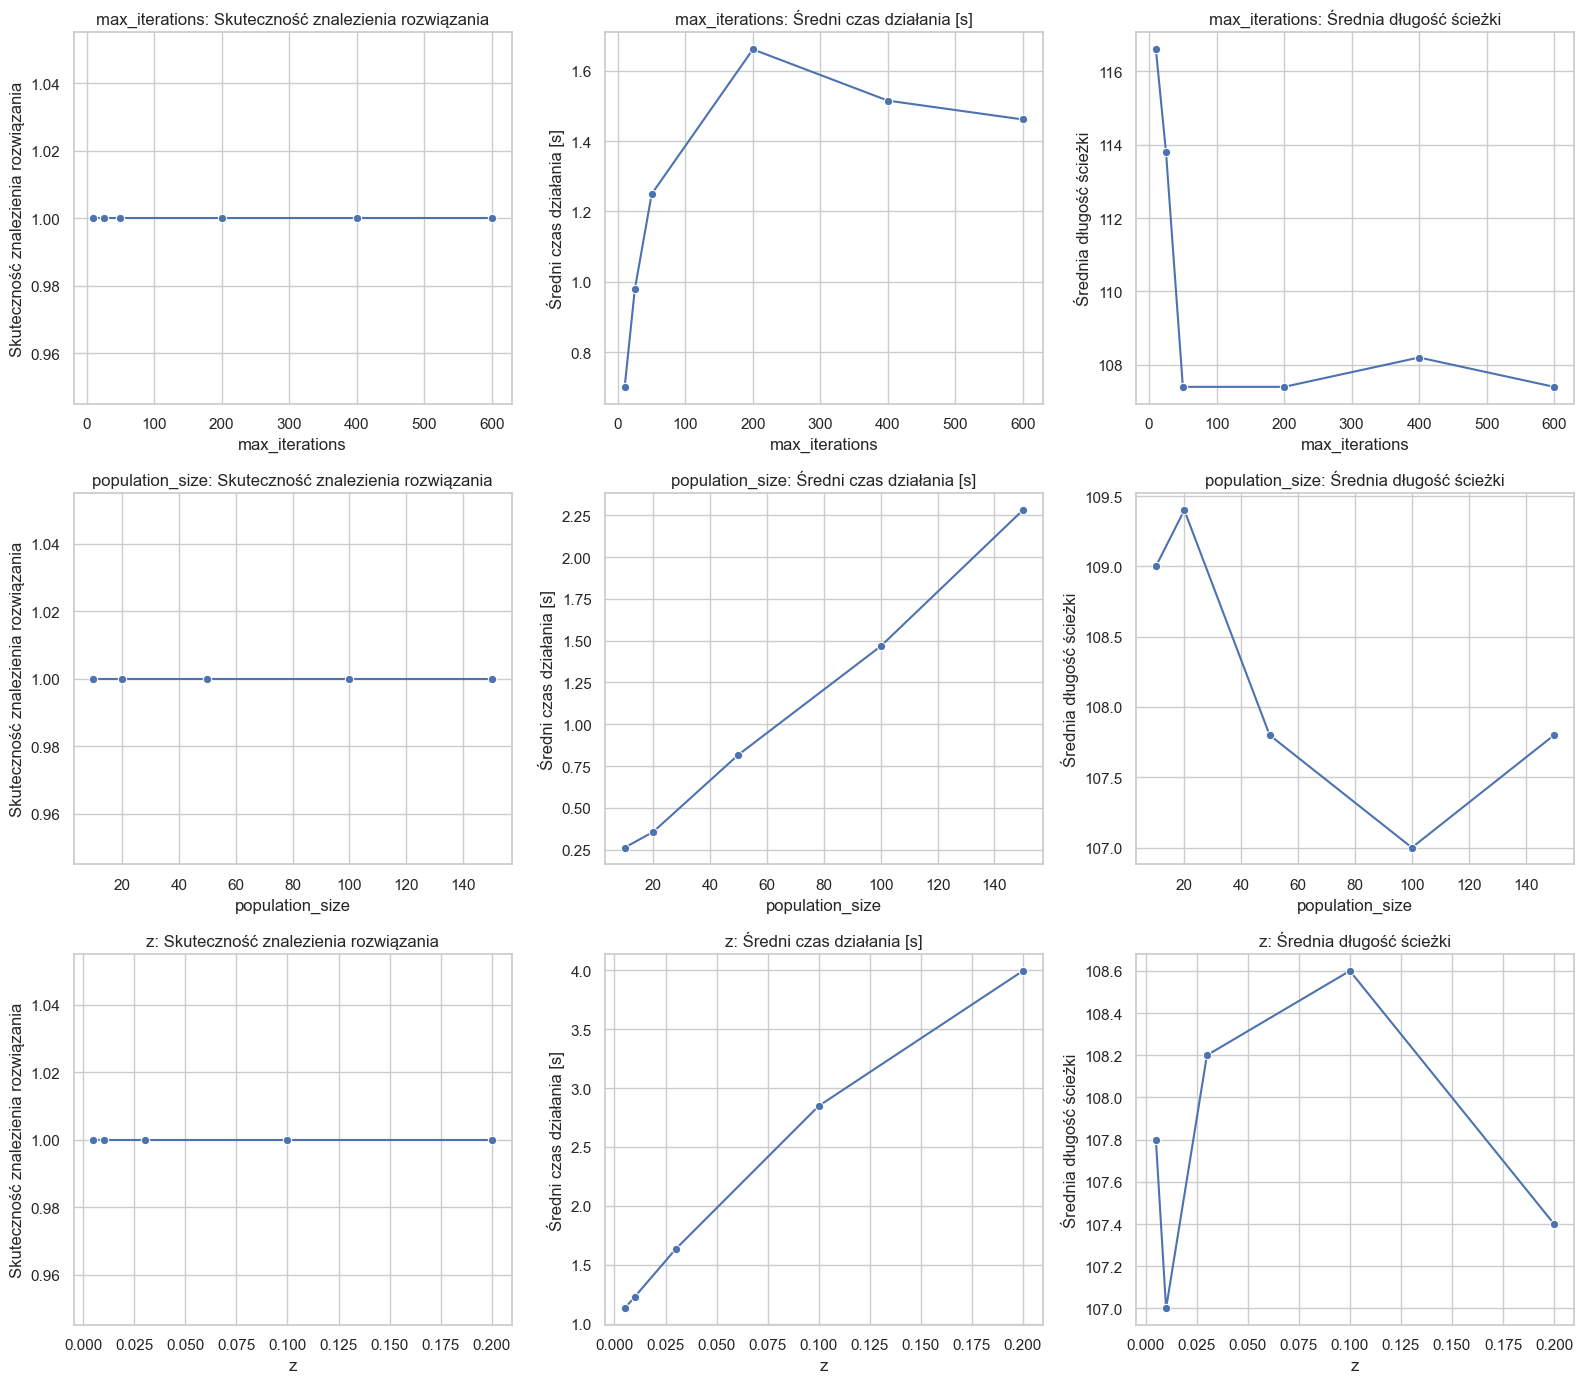

In [15]:
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
metrics = [
    ('success_rate', 'Skuteczność znalezienia rozwiązania'),
    ('mean_time_s', 'Średni czas działania [s]'),
    ('mean_path_length', 'Średnia długość ścieżki'),
]

for row_idx, parameter_name in enumerate(['max_iterations', 'population_size', 'z']):
    subset = sensitivity_summary_df[
        sensitivity_summary_df['tested_parameter'] == parameter_name
    ].sort_values('tested_value')

    for col_idx, (metric, title) in enumerate(metrics):
        ax = axes[row_idx, col_idx]
        sns.lineplot(data=subset, x='tested_value', y=metric, marker='o', ax=ax)
        ax.set_title(f'{parameter_name}: {title}')
        ax.set_xlabel(parameter_name)
        ax.set_ylabel(title)

plt.tight_layout()
plt.show()
